# **Task 1 Dataset Understanding & Analysis Planning**

**Analysis Objectives**


1.   Analyze order distribution across cities and restaurants.
2.   Evaluate delivery performance & delivery time
3.   understand customer behavior through ratings and ordering patterns
4.   Identify the most popular food items



**Importing libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Load , Read & Check The DataSet**

In [2]:
df = pd.read_csv("/content/Food_Delivery.csv")

In [3]:
#Display first 5 rows
df.head()


,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
0,1,1102,Kebab House,alex,2024-01-01 00:00:00,40.0,Kebab,4,265,13,Wallet,1.0
1,2,1435,Sushi World,alex,2024-01-01 01:00:00,30.0,Pasta,2,241,5,Card,3.0
2,3,1860,Burger Town,Cairo,2024-01-01 02:00:00,NaN,Pasta,3,240,13,Wallet,2.0
3,4,1270,Sushi World,cairo,2024-01-01 03:00:00,43.0,Kebab,3,269,16,Wallet,2.0
4,5,1106,Burger Town,Cairo,2024-01-01 04:00:00,12.0,Pizza,1,129,17,Cash,2.0


In [4]:
print("Dataset loaded successfully")

Dataset loaded successfully


**Dataset Shape**

In [5]:
print("number of rows & columns :",df.shape)

number of rows & columns : (2050, 12)


All column names

In [6]:
df.columns

Index(['order_id', 'customer_id', 'restaurant', 'city', 'order_date',
       'delivery_time_minutes', 'item', 'quantity', 'price', 'discount',
       'payment_method', 'rating'],
      dtype='object')

Data Types

In [7]:
df.dtypes

,0
order_id,int64
customer_id,int64
restaurant,object
city,object
order_date,object
delivery_time_minutes,float64
item,object
quantity,int64
price,int64
discount,int64


Data Summary

In [8]:
df.describe()

,order_id,customer_id,delivery_time_minutes,quantity,price,discount,rating
count,2050.000000,2050.000000,1943.000000,2050.000000,2050.000000,2050.000000,1945.000000
mean,1000.057073,1499.454634,35.249614,2.650244,172.146829,14.497561,2.972751
std,577.001897,294.397792,18.997235,2.402641,71.659016,8.451408,1.412677
min,1.000000,1000.000000,-3.000000,1.000000,50.000000,0.000000,1.000000
25%,501.250000,1232.000000,26.000000,1.000000,111.000000,7.000000,2.000000
50%,1001.500000,1505.000000,35.000000,3.000000,170.000000,15.000000,3.000000
75%,1497.750000,1761.000000,43.000000,4.000000,233.750000,22.000000,4.000000
max,2000.000000,1998.000000,292.000000,41.000000,299.000000,29.000000,5.000000


**Dataset informatio**

In [9]:
print("Some Informations about the DataSet:")
print("")
print(df.info())

Some Informations about the DataSet:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2050 entries, 0 to 2049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               2050 non-null   int64  
 1   customer_id            2050 non-null   int64  
 2   restaurant             2050 non-null   object 
 3   city                   1947 non-null   object 
 4   order_date             2050 non-null   object 
 5   delivery_time_minutes  1943 non-null   float64
 6   item                   2050 non-null   object 
 7   quantity               2050 non-null   int64  
 8   price                  2050 non-null   int64  
 9   discount               2050 non-null   int64  
 10  payment_method         2050 non-null   object 
 11  rating                 1945 non-null   float64
dtypes: float64(2), int64(5), object(5)
memory usage: 192.3+ KB
None


**Random 5 Sampels**

In [10]:
df.sample(5)

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating
989,990,1882,Pasta Point,Cairo,2024-02-11 05:00:00,25.0,Pizza,3,267,21,Wallet,5.0
1485,1486,1096,Sushi World,Cairo,2024-03-02 21:00:00,40.0,Sushi,2,142,9,Card,1.0
503,504,1791,Pasta Point,Cairo,2024-01-21 23:00:00,23.0,Pizza,2,57,22,Card,4.0
676,677,1905,Pizza Hub,Cairo,2024-01-29 04:00:00,23.0,Kebab,1,263,25,Card,2.0
1431,1432,1409,Pasta Point,alex,2024-02-29 15:00:00,23.0,Sushi,1,94,4,Card,2.0


****Dataset Understanding****

**1/Dataset dimensions:** The dataset contains 2050 rows and 12 columns

**2/Column descriptions**
  
* order_id: Unique identifier for each order.
* customer_id: Unique identifier for each customer.
* restaurant: Restaurant where the order was placed.
* city: City where the order was delivered.
* order_date: Date and time when the order was placed.
* delivery_time_minutes: Delivery duration in minutes.
* item: Food item ordered.
* quantity: Number of items ordered.
* price: Total order price before discount.
* discount: Discount applied to the order.
* payment_method: Payment method used (Cash, Card, or Wallet).
* rating: Customer rating (1–5).


**Data Types:**
* Numerical:
  * delivery_time_minutes
  * quantity
  * price
  * discount
  * rating

* Categorical:
  * order_id
  * customer_id
  * restaurant
  * city
  * order_date
  * item
  * payment_method


**Initial observations**

* Order date is prefered to be Datetime
* There are missing values
* In City column there are Inconsistent formatting
* There are numerical and categorical data

# **Task 2 Data Quality Assessment & Preparation**

check missing values

In [11]:
print("Number of the missing values in each column:")
print(df.isnull().sum())


Number of the missing values in each column:
order_id                   0
customer_id                0
restaurant                 0
city                     103
order_date                 0
delivery_time_minutes    107
item                       0
quantity                   0
price                      0
discount                   0
payment_method             0
rating                   105
dtype: int64


Check duplicate rows


In [12]:
print("Number of the Duplicated rows:", df.duplicated().sum())


Number of the Duplicated rows: 50


Check Data Types

In [13]:
df.dtypes

,0
order_id,int64
customer_id,int64
restaurant,object
city,object
order_date,object
delivery_time_minutes,float64
item,object
quantity,int64
price,int64
discount,int64


Check unique values

In [14]:
print("The Unique Cities:", df["city"].unique())
print("The Unique Cities:", df["item"].unique())
print("The Unique Cities:", df["restaurant"].unique())
print("The Unique Cities:", df["payment_method"].unique())


The Unique Cities: ['alex' 'Cairo' 'cairo' nan 'Alex' 'Giza' 'CAIRO']
The Unique Cities: ['Kebab' 'Pasta' 'Pizza' 'Burger' 'Sushi']
The Unique Cities: ['Kebab House' 'Sushi World' 'Burger Town' 'Pizza Hub' 'Pasta Point']
The Unique Cities: ['Wallet' 'Card' 'Cash']


Handle Duplicate Records

In [15]:
df= df.drop_duplicates()

In [16]:
print("Number Of Duplicated columns after removing them:", df.duplicated().sum())

Number Of Duplicated columns after removing them: 0


Handle Missing Values

In [17]:
print("The new number of missing values after removing duplicates:",df.isnull().sum())

The new number of missing values after removing duplicates: order_id                   0
customer_id                0
restaurant                 0
city                     100
order_date                 0
delivery_time_minutes    100
item                       0
quantity                   0
price                      0
discount                   0
payment_method             0
rating                   100
dtype: int64


In [18]:
df["delivery_time_minutes"] = df["delivery_time_minutes"].fillna(df["delivery_time_minutes"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())
df['city'] = df['city'].fillna("Unknown")


In [19]:
print("number of missing Values after handling:", df.isnull().sum())

number of missing Values after handling: order_id                 0
customer_id              0
restaurant               0
city                     0
order_date               0
delivery_time_minutes    0
item                     0
quantity                 0
price                    0
discount                 0
payment_method           0
rating                   0
dtype: int64


Resolve Data Inconsistencies

In [20]:
df["city"] = df["city"].replace({
    "alex" : "Alex",
    "cairo" : "Cairo",
    "CAIRO" : "Cairo"
})

df["city"] = df["city"].str.strip()
df["restaurant"] = df["restaurant"].str.strip()
df["item"] = df["item"].str.strip()
df["payment_method"] = df["payment_method"].str.strip()

In [21]:
print("The Unique Cities:", df["city"].unique())


The Unique Cities: ['Alex' 'Cairo' 'Unknown' 'Giza']


Prepare Data for Analysis

In [22]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [23]:
df.dtypes

,0
order_id,int64
customer_id,int64
restaurant,object
city,object
order_date,datetime64[ns]
delivery_time_minutes,float64
item,object
quantity,int64
price,int64
discount,int64


In [24]:
df["month"] = df["order_date"].dt.month_name()


In [25]:
df.sample(5)

,order_id,customer_id,restaurant,city,order_date,delivery_time_minutes,item,quantity,price,discount,payment_method,rating,month
1330,1331,1880,Burger Town,Alex,2024-02-25 10:00:00,48.0,Burger,1,117,9,Cash,3.0,February
1146,1147,1847,Pasta Point,Cairo,2024-02-17 18:00:00,21.0,Sushi,3,168,27,Wallet,4.0,February
1808,1809,1236,Pasta Point,Alex,2024-03-16 08:00:00,48.0,Sushi,1,212,7,Card,4.0,March
1443,1444,1525,Kebab House,Cairo,2024-03-01 03:00:00,28.0,Pasta,1,114,17,Cash,5.0,March
1743,1744,1181,Sushi World,Cairo,2024-03-13 15:00:00,14.0,Burger,3,133,24,Wallet,2.0,March


Check Outliers

In [26]:
df.describe()

,order_id,customer_id,order_date,delivery_time_minutes,quantity,price,discount,rating
count,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,1498.918500,2024-02-11 15:29:59.999999744,35.308500,2.657500,172.035000,14.521500,2.982500
min,1.000000,1000.000000,2024-01-01 00:00:00,-3.000000,1.000000,50.000000,0.000000,1.000000
25%,500.750000,1232.000000,2024-01-21 19:45:00,27.000000,1.000000,111.000000,7.000000,2.000000
50%,1000.500000,1503.000000,2024-02-11 15:30:00,35.000000,3.000000,170.000000,15.000000,3.000000
75%,1500.250000,1761.000000,2024-03-03 11:15:00,42.000000,4.000000,233.000000,22.000000,4.000000
max,2000.000000,1998.000000,2024-03-24 07:00:00,292.000000,41.000000,299.000000,29.000000,5.000000
std,577.494589,294.301136,NaN,18.620249,2.425311,71.491428,8.475698,1.375914


In [27]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print("lower Bound:", lower)
print("upper Bound:", upper)
print("Number of Outliers:", len(outliers))

lower Bound: -72.0
upper Bound: 416.0
Number of Outliers: 0


In [28]:
Q11 = df["delivery_time_minutes"].quantile(0.25)
Q33 = df["delivery_time_minutes"].quantile(0.75)
IQR2 = Q33 - Q11

lower2 = Q11 - 1.5 * IQR2
upper2 = Q33 + 1.5 * IQR2

outliers2 = df[(df["delivery_time_minutes"] < lower2) | (df["delivery_time_minutes"] > upper2)]
print("lower Bound:", lower2)
print("upper Bound:", upper2)
print("Number of Outliers:", len(outliers2))

lower Bound: 4.5
upper Bound: 64.5
Number of Outliers: 35


Handel Outliers

In [29]:
print(df["delivery_time_minutes"].min())
print(df["delivery_time_minutes"].max())

-3.0
292.0


In [30]:
#removing the negative values because there is no time in negative
df[df["delivery_time_minutes"] < 0]
df = df[df["delivery_time_minutes"] >= 0]

In [31]:
# Checking new data
print(df["delivery_time_minutes"].min())
print(df["delivery_time_minutes"].max())

0.0
292.0


Verify dataset ready

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1997 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               1997 non-null   int64         
 1   customer_id            1997 non-null   int64         
 2   restaurant             1997 non-null   object        
 3   city                   1997 non-null   object        
 4   order_date             1997 non-null   datetime64[ns]
 5   delivery_time_minutes  1997 non-null   float64       
 6   item                   1997 non-null   object        
 7   quantity               1997 non-null   int64         
 8   price                  1997 non-null   int64         
 9   discount               1997 non-null   int64         
 10  payment_method         1997 non-null   object        
 11  rating                 1997 non-null   float64       
 12  month                  1997 non-null   object        
dtypes: datet

In [33]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant,0
city,0
order_date,0
delivery_time_minutes,0
item,0
quantity,0
price,0
discount,0


In [34]:
df.duplicated().sum()

np.int64(0)

Now the Data is clean and ready for analysis

there were 35 potential outliers in delivery_time_minutes column.
there were invalid values with negativee numbers so they were removed.

*   while the higher values were retained because they may represent real business events such as traffic delays or operational issues rather than data entry errors.


# **Task 3 Exploratory Data Analysis (EDA)**

Descriptive Statistics

In [35]:
df.describe()

,order_id,customer_id,order_date,delivery_time_minutes,quantity,price,discount,rating
count,1997.000000,1997.000000,1997,1997.000000,1997.000000,1997.000000,1997.000000,1997.000000
mean,999.830245,1499.002003,2024-02-11 14:49:48.883324928,35.365048,2.656985,172.073110,14.521282,2.981973
min,1.000000,1000.000000,2024-01-01 00:00:00,0.000000,1.000000,50.000000,0.000000,1.000000
25%,500.000000,1232.000000,2024-01-21 19:00:00,27.000000,1.000000,111.000000,7.000000,2.000000
50%,999.000000,1503.000000,2024-02-11 14:00:00,35.000000,3.000000,170.000000,15.000000,3.000000
75%,1499.000000,1761.000000,2024-03-03 10:00:00,42.000000,4.000000,233.000000,22.000000,4.000000
max,2000.000000,1998.000000,2024-03-24 07:00:00,292.000000,41.000000,299.000000,29.000000,5.000000
std,577.580137,294.323982,NaN,18.576885,2.426890,71.520991,8.470459,1.375303


**Analyze Individual Variables**



**Numerical Variables**

Price Distribution

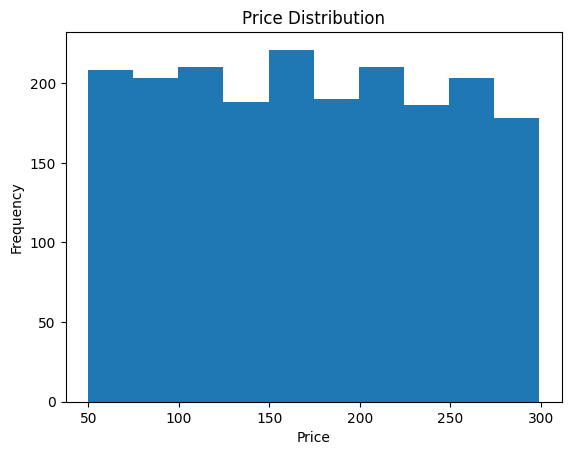

In [36]:
plt.hist(df["price"], bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Delivery Time Distribution

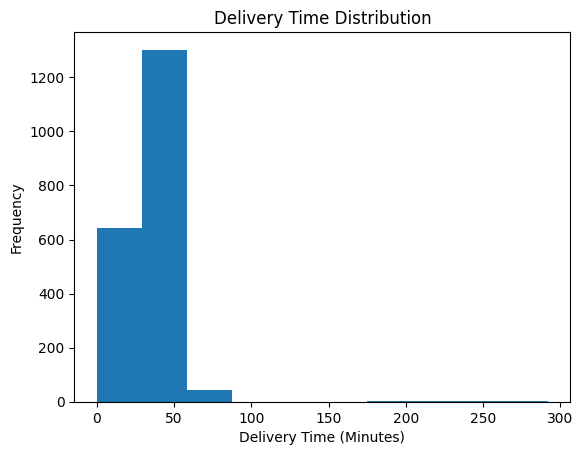

In [37]:
plt.hist(df["delivery_time_minutes"], bins=10)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.show()

Rating Distribution

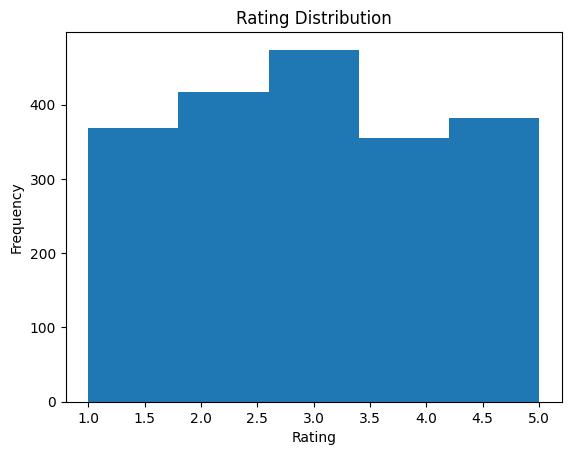

In [38]:
plt.hist(df["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Quantity Distribution

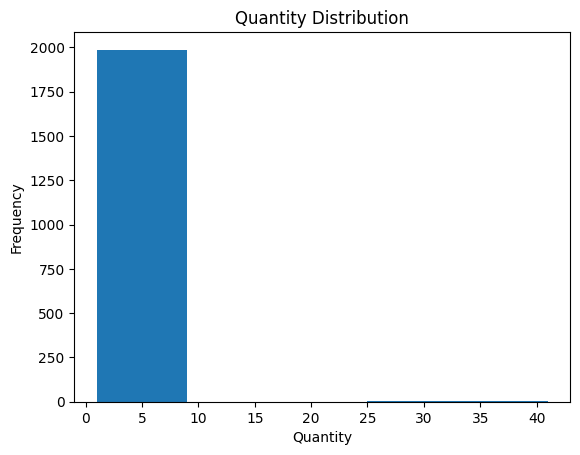

In [39]:
plt.hist(df["quantity"], bins=5)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

Price

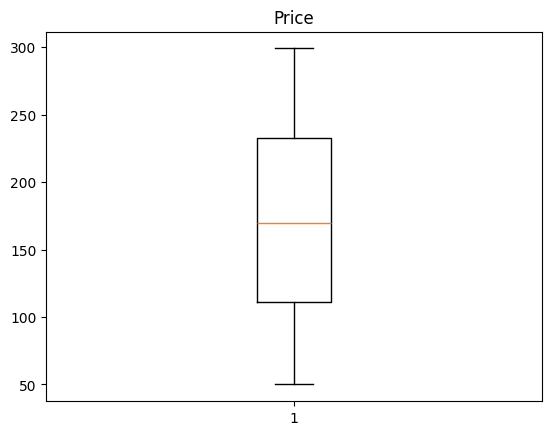

In [40]:
plt.boxplot(df["price"])
plt.title("Price")
plt.show()

Delivery Time

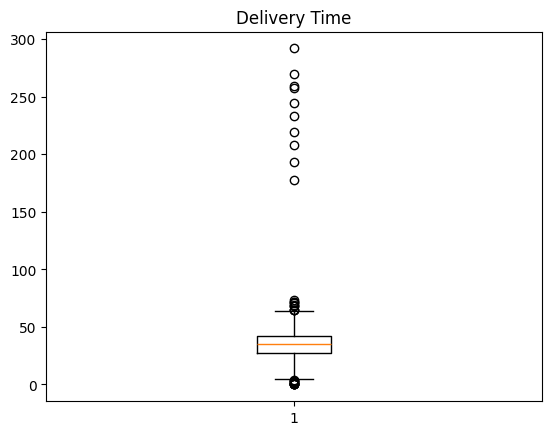

In [41]:
plt.boxplot(df["delivery_time_minutes"])
plt.title("Delivery Time")
plt.show()

Rating

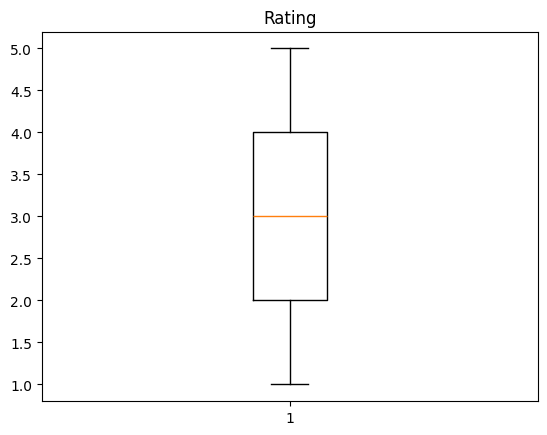

In [42]:
plt.boxplot(df["rating"])
plt.title("Rating")
plt.show()

**Categorical Variables**

City Vs Orders

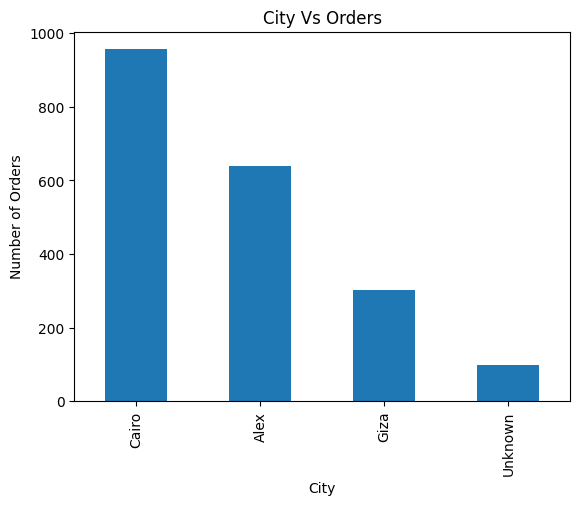

In [43]:
df["city"].value_counts().plot(kind="bar")
plt.title("City Vs Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.show()

Restaurant Vs Orders

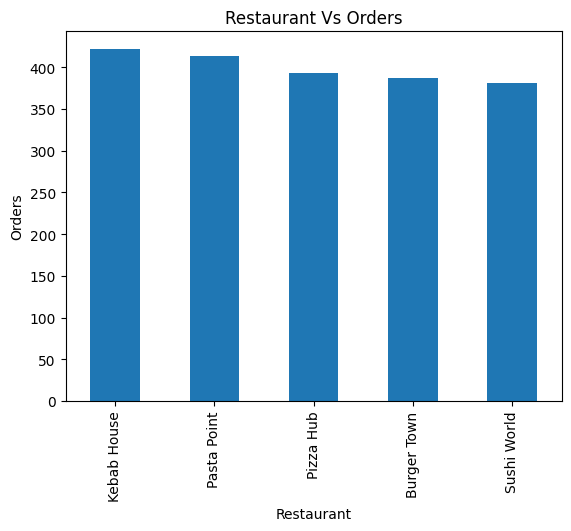

In [44]:
df["restaurant"].value_counts().plot(kind="bar")
plt.title("Restaurant Vs Orders")
plt.xlabel("Restaurant")
plt.ylabel("Orders")
plt.show()

Payment Methods

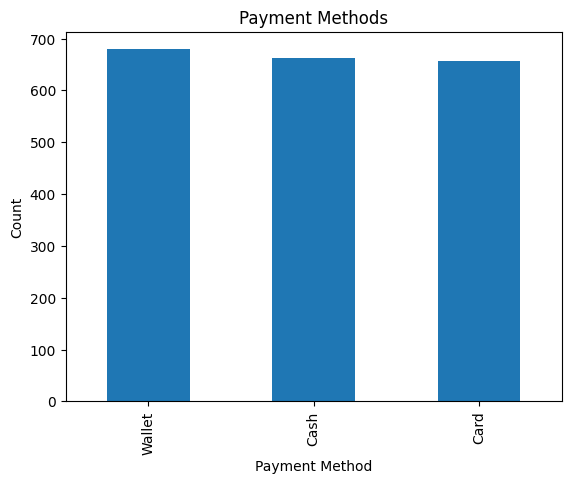

In [45]:
df["payment_method"].value_counts().plot(kind="bar")
plt.title("Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.show()

**Explore Relationships Between Variables**

price by city

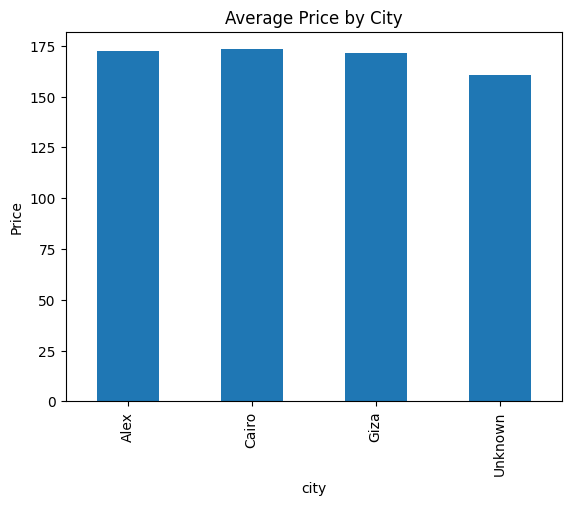

In [46]:
df.groupby("city")["price"].mean().plot(kind="bar")
plt.title("Average Price by City")
plt.ylabel("Price")
plt.show()

Average Delivery Time by Restaurant

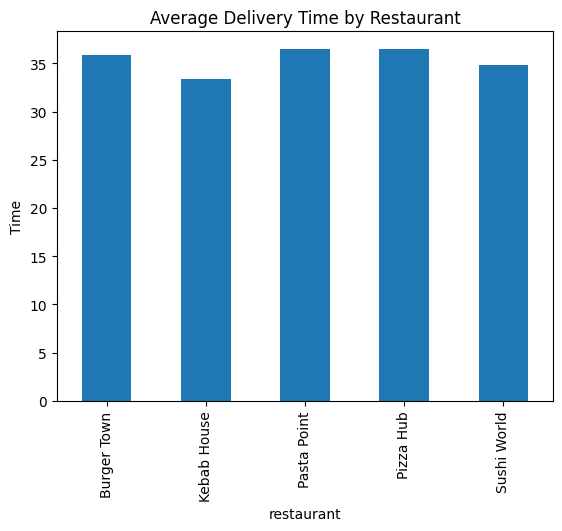

In [47]:
df.groupby("restaurant")["delivery_time_minutes"].mean().plot(kind="bar")
plt.title("Average Delivery Time by Restaurant")
plt.ylabel("Time")
plt.show()

Average Ratings by Restaurant

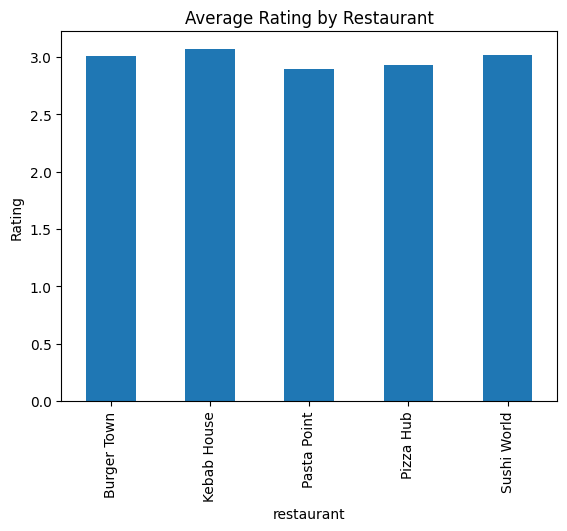

In [48]:
df.groupby("restaurant")["rating"].mean().plot(kind="bar")
plt.title("Average Rating by Restaurant")
plt.ylabel("Rating")
plt.show()

**Step 4: Review Data Subsets**


Compare Cities

In [49]:
df.groupby("city")[["price","rating","delivery_time_minutes"]].mean()

,price,rating,delivery_time_minutes
city,,,
Alex,172.333333,3.028169,35.079812
Cairo,173.254184,2.936192,35.173640
Giza,171.612583,2.927152,35.930464
Unknown,160.510000,3.290000,37.310000


Compare Restaurants

In [50]:
df.groupby("restaurant")[["price","rating","delivery_time_minutes"]].mean()

,price,rating,delivery_time_minutes
restaurant,,,
Burger Town,168.870801,3.010336,35.886305
Kebab House,172.009479,3.068720,33.317536
Pasta Point,169.190821,2.891304,36.429952
Pizza Hub,176.755725,2.926209,36.480916
Sushi World,173.698163,3.013123,34.795276


compare payments

In [51]:
df.groupby("payment_method")[["price","rating"]].mean()

,price,rating
payment_method,,
Card,169.864329,2.967988
Cash,174.203927,2.974320
Wallet,172.129602,3.002946


**Step 5: Feature Engineering
**

Price_Category

In [52]:
print(df["price"].min())
print(df["price"].max())

50
299


In [53]:
df["price_category"] = pd.cut(
    df["price"],
    bins = [0,50,150,400],
    labels = ["low","medium","high"]
)
df["price_category"].value_counts()

,count
price_category,
high,1178
medium,811
low,8


**Step 6: Perform Data Visualization**


The Most Ordered Items "Barchart"



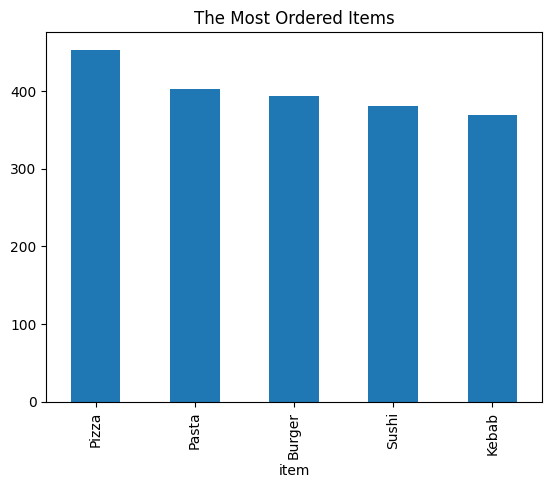

In [54]:
df["item"].value_counts().plot(kind="bar")
plt.title("The Most Ordered Items")
plt.show()

Orders by Month"LineChart"

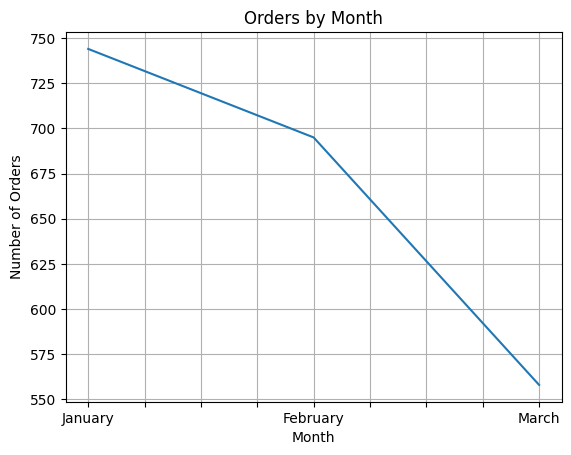

In [55]:
months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["month"].value_counts().plot(kind="line")

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True)
plt.show()

Rating Distribution"Histogram"

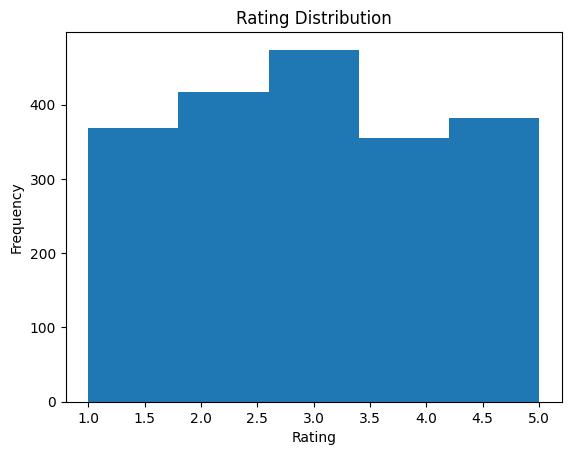

In [56]:
plt.hist(df["rating"], bins=5)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Price category vs Rating

/tmp/ipykernel_2058/2830726150.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_category")["rating"].mean().plot(kind="bar")


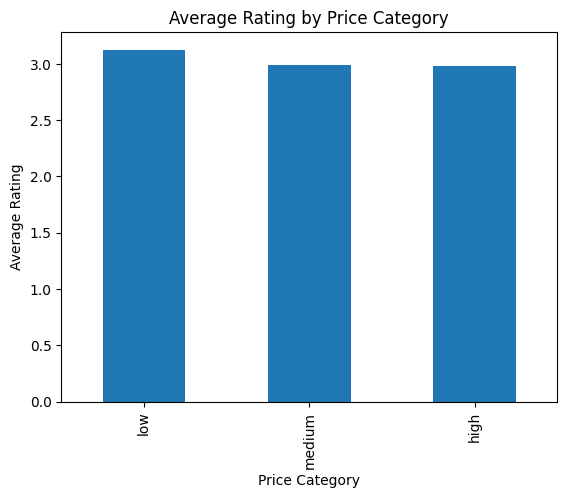

In [57]:
df.groupby("price_category")["rating"].mean().plot(kind="bar")

plt.title("Average Rating by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Average Rating")
plt.show()

In [58]:
df.to_csv("Cleaned_Dataset.csv", index = False)